<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Hypothesis Testing <a class="tocSkip">

In this notebook we will see:
- the **hypothesis testing framework**: $H_0$, significance level $\alpha$, test statistic, $p$-value, decision,
- **common tests** ready to use off-the-shelf: z-test, t-test, Kolmogorov–Smirnov, Mann–Kendall,
- the **bootstrap**, to build the PDF of the statistic when no theoretical one is available,
- what we can — and <u>cannot</u> — **conclude** from a test and its $p$-value.

# Setup

In [1]:
!pip install pymannkendall --quiet

In [2]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Repository:
https://github.com/AstroStat-Academy/astrostat-school-7.git

Branch:
main

Working in:
/content/astrostat-school-7/Hypothesis_Testing

Content:
	 ['Hypothesis_Testing.ipynb', 'data', 'images']


In [3]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


## Preamble

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Q:** If we have a statistic $T$ distributed as in the plot below, how can we calculate the probability of obtaining a value as large as $\bar{T}$ or larger?

</div>

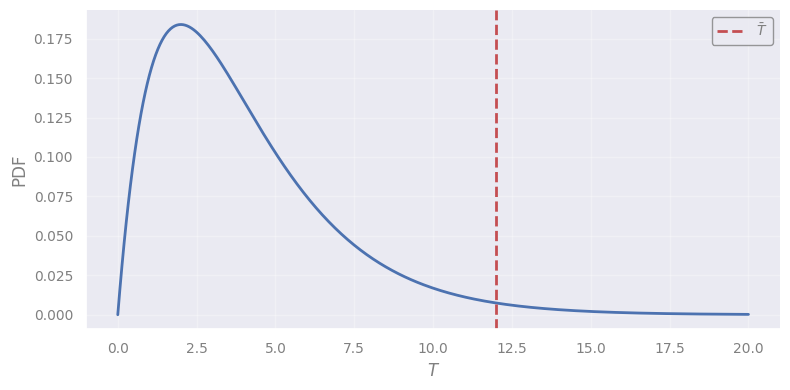

In [4]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# A distribution bounded at 0 and unbounded for large T (e.g. a chi-square shape)
T_dist = stats.chi2(df=4)

T_plot = np.linspace(0, 20, 300)
pdf_plot = T_dist.pdf(T_plot)

T_bar = 12.0  # the observed value we mark on the plot

plt.plot(T_plot, pdf_plot, "C0", lw=2)
plt.axvline(T_bar, ls="--", lw=2, color="C3", label=r"$\bar{T}$")
plt.xlabel("$T$")
plt.ylabel("PDF")
plt.legend(loc="upper right")
plt.show()

# A step-by-step case to build intuition

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

A **hypothesis test** evaluates whether the observed **sample**<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;$\dots$ is compatible with a **hypothesis** about a **model**<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&ensp;&emsp;&emsp;&emsp;&emsp;$\dots$ representing the unknown **data-generating process**.
</div><br>

Let us use a practical scenario to build an **intuition** about how Hypothesis Testing works.


## The sample

A research team has studied a sample of **Globular Clusters** (**GCs**) and measured their masses.

> _PS: We will work in log-scale._


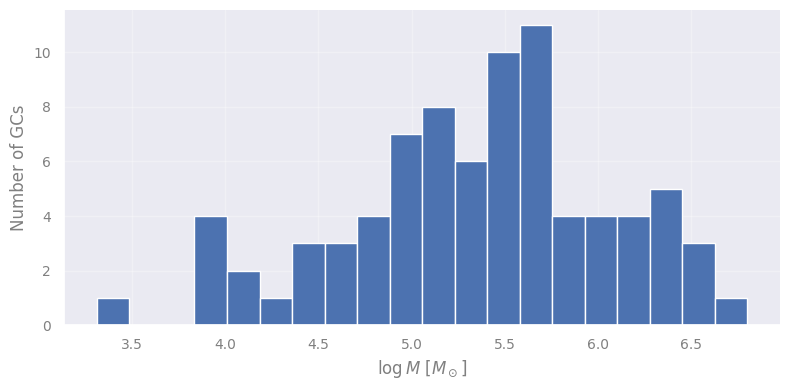

In [5]:
import numpy as np
import pandas as pd
from scipy import stats

df_masses = pd.read_csv("data/GC_masses.csv", header=None, names=["mass"])

# Extract the data as a numpy array, in log-scale
X = np.log10(df_masses["mass"].to_numpy())

plt.hist(X, bins=20)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("Number of GCs")
plt.show()

## The model

**Globis & Clusterton (2022)** suggest a model described by a **normal distribution**:

$$\log_{10}(M/M_\odot) \sim \mathcal{N}(\mu_0,\, 1)$$

peaking at $\mu_0 = 5.5$.

Let's **overplot** the model on the data for a quick comparison.


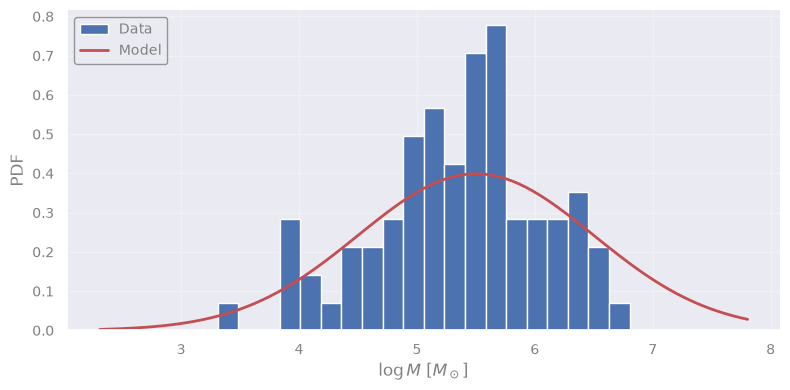

In [ ]:
mu_0  = 5.5
std_0 = 1.0

logm_for_plot = np.linspace(min(X)-1, max(X)+1, 100)
model_prob_for_plot = stats.norm(mu_0, std_0).pdf(logm_for_plot)

plt.hist(X, bins=20, density=True, label="Data")
plt.plot(logm_for_plot, model_prob_for_plot, "r-", lw=2, label="Model")
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF")
plt.legend(loc="upper left")
plt.show()

## The property

**Q:** The model and the data look similar. Is this enough to say they are **compatible**?

**A:** No $\rightarrow$ we must translate it into a **measurable quantity**: a model **property** that we can <u>also estimate</u> from the **data**, and then compare.

Let's go simple $\rightarrow$ We use the **location** of the peak — the **mean $\mu$**.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

In this case, the **property** we investigate is a **parameter**.

But, in principle, we may use <u>any</u> property we can think of — e.g.:
- the **location** of the peak of the model (_to be compared with that of the data_)
- the **height** of the peak (_to be compared with that of the data_)
- the **shape** of the model (_to be compared with that of the data_)
- _etc._

</div>


## The hypothesis

The authors propose the **hypothesis**:

> _GC formation in galaxies (the **data-generating process**) produces masses whose distribution (described by our **model**) has an average equal to 5.5._

Or, equivalently:

> _The true mean $\mu$ of the GC distribution equals the model value $\mu_0$:_
> >
> $H_0:\mu=\mu_0.$

## The statistic

We cannot measure $\mu$ on the population $\rightarrow$ We now need a **statistic** <u>on the sample</u> to verify the claim.

We will use the **sample mean**:

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \tag{1} $$

Here, $\bar{x}$ serves as a replacement of the _unknown_ $\mu$.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

So, to summarize:

| | |
|---|---|
| **Data-generating process** | GC formation in real galaxies |
| **Hypothesis** | The population has mean $\mu$ equal to $\mu_0 = 5.5$ |
| **Statistic to probe the claim** | The sample mean $\bar{x}$ |

</div>

## Evaluating the statistic

We shall now calculate $\bar{x}$ and compare against $\mu_0$.

In [ ]:
x_bar = np.mean(X)

print(f"MODEL:  mu_0  = {mu_0:.1f}")
print(f"SAMPLE: x_bar = {x_bar:.2f}")

MODEL:  mu_0  = 5.5
SAMPLE: x_bar = 5.35


We shall check whether:

- $\mu_0$ **very different** from $\bar{x}$ $\rightarrow$ **reject** the hypothesis that the data were generated by the model
- $\mu_0$ **similar** to $\bar{x}$ &emsp;&emsp;&emsp;&emsp;&emsp; $\rightarrow$ _we discuss this later ..._

 We need the **Probability Distribution Function** (**PDF**) of the test **statistic**.

If we know the PDF of the statistic, we can calculate **probabilities** — In our example, we can calculate the probability of:
> _Having measured a sample's **$\bar{x}$** if the expectation is $\mu_0 = 5.5$_


## Building the statistic's PDF

We can build the PDF of the statistic if we consider the _implicit_ **assumptions**:

1. **Assumption** that the data are **i.i.d.**.
2. **Assumption**, under $H_0$, that the **model** describes the data-generating process.

Assumptions have **implications** we can exploit.

1. Assumption 1 implies, via the **Central Limit Theorem**, that the PDF of $\bar{x}$ is a **Gaussian**:

    $$\bar{x} \sim \mathcal{N}(\mu_{\bar{x}}, \sigma_{\bar{x}})$$

2. Assumption 2 implies that the Gaussian shall be centered on $\mu_0$ $\rightarrow$ $\mu_{\bar{x}} = \mu_0$.

**Q:** Ok, but what about $\sigma_{\bar{x}}$?

**A:** We can estimate it with the **standard error of the mean**, $s_{\bar{x}}$.

Therefore the PDF for $\bar{x}$, under $H_0$, is:

$$\bar{x} \sim \mathcal{N}(\mu_0, s_{\bar{x}})$$
<br>

With the PDF at hand, calculating the probability of observing the measured $\bar{x}$ is just the **integral of the extremes**:

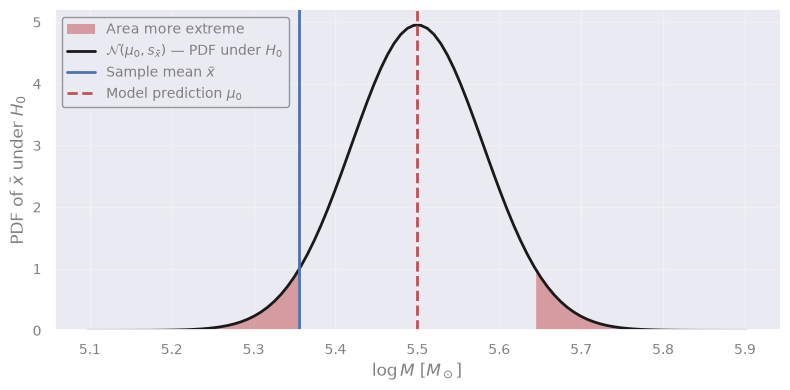

In [ ]:
s_x_bar = stats.sem(X)

diff = abs(x_bar - mu_0)

x_plot = np.linspace(mu_0 - 5 * s_x_bar, mu_0 + 5 * s_x_bar, 100)
xx_before = np.linspace(mu_0 - 5 * s_x_bar, mu_0 - diff, 100)
xx_after = np.linspace(mu_0 + diff, mu_0 + 5 * s_x_bar, 100)

null_distribution = stats.norm(mu_0, s_x_bar)
y_plot = null_distribution.pdf(x_plot)

plt.fill_between(xx_before, null_distribution.pdf(xx_before), 0, color="r", ec="none", alpha=0.5, label="Area more extreme")
plt.fill_between(xx_after, null_distribution.pdf(xx_after), 0, color="r", ec="none", alpha=0.5)
plt.plot(x_plot, y_plot, "k-", lw=2, label=r"$\mathcal{N}(\mu_0, s_{\bar{x}})$ — PDF under $H_0$")
plt.axvline(x_bar, ls="-", color="b", label=r"Sample mean $\bar{x}$")
plt.axvline(mu_0, ls="--", lw=2, color="r", label=r"Model prediction $\mu_0$")
plt.legend(loc="upper left")
plt.ylim(ymin=0.0)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel(r"PDF of $\bar{x}$ under $H_0$")
plt.show()


In [ ]:
area_more_extreme = 1 - (null_distribution.cdf(mu_0+diff) - null_distribution.cdf(mu_0-diff))
print(f"Area more extreme — p: {area_more_extreme:.4f}")

Area more extreme — p: 0.0716


_NOTE: We consider both **wings** because we want to test both a very **large** and a very **low** value for $\bar{x}$._

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

**One/Two-sided** tests:

- Two-sided test asks _is the parameter different?_
- One-sided test asks _is the parameter larger / smaller?_

</div>

## What is this probability?

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**p-value**

The probability, under $H_0$, of observing a test statistic at least as extreme as the one actually measured<br>

</div>

_i.e. the area under the PDF (assumed true under $H_0$) that lies at least as far from $\mu_0$ as the observed value._

Equivalently:

> _How **surprising** the data is, in a world where the model is true._

The smaller this number, the more safely we can reject the model.


## Thresholding & Decision

We found a **$p$-value** of 0.07 — if the model were true, data this extreme would occur only $\sim 7\%$ of the time.

**Q:** Can we risk it?

**A:** It is **our choice** to consider our "threshold" or **significance level** $\alpha$!

If we had decided **before looking at the data** to use a 5% threshold, then our conclusion would be:

> _"We do not reject the model, with a significance level of 5%"_


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

**Choosing the significance level**

There is <u>no</u> rule $\rightarrow$ Just that it should be decided **before** the analysis.

This is to avoid **biasing** our conclusions by:
- **relaxing** our criteria for models that we like, or
- making it **harder** for models that we don't like.

</div>

In Astronomy, $2 + 2 \simeq 5$, so we often use 0.5, 1 or 5%. In Nuclear Physics and precision experiments often $10^{-7}$ or $10^{-10}$ are used!

# The Hypothesis Testing Framework
    Let's formalize what we learnt

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

Hypothesis Testing answers the following:

> _Is the observed data compatible with a claim about a model, or unusual enough that we should reject it?_

$\dots$ while keeping the probability of falsely rejecting bounded by a level **$\alpha$** chosen up front.

</div>
<br>

The _whole process_ is outlined as follows:

> **Step 1**: Define the **null hypothesis** ($H_0$).

> **Step 2**: Decide on a **significance level** $\alpha$ that we are comfortable with.

> **Step 3**: Pick the **statistic** and corresponding PDF under $H_0$.

> **Step 4**: Compute the **$p$-value**.

> **Step 5**: Decision.


## Step 1. Null and Alternative Hypothesis

Any test starts with 2 mutually-exclusive statements about the world.

- $H_{0}$: **Null Hypothesis**; encodes the *status quo* — the claim we are willing to keep if the data does not strongly contradict it.
- $H_{1}$: **Alternative Hypothesis**; encodes the *challenger* — the claim we accept only if the data points clearly away from $H_{0}$.

The test is **conservative**: $H_{0}$ is innocent until proven guilty.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

$\rightarrow$ Pick the null so that <em>incorrectly rejecting it</em> is the **more expensive** mistake.

_Examples:_

- If you are evaluating a new detection pipeline against the standard one:<br>
  > $H_0$ should be $\rightarrow$ "the new pipeline does not perform better than the standard one"

  _(You do not want to adopt a pipeline that is actually worse)_

- If you are evaluating whether a telescope's calibration has drifted:<br>

  > $H_0$ should be $\rightarrow$ "the calibration has not drifted"

  _(You do not want to falsely flag good data as unreliable)_

</div>


## Step 2. Decide on a significance level

This is the **false-alarm rate** we accept: if $H_0$ were true, our procedure would wrongly reject it in a fraction $\alpha$ of experiments.

> _E.g., a significance level of $5\%$, i.e. $\alpha = 0.05$._


## Step 3. Pick the statistic

Pick a sample statistic that can measure the property under claim.

>_E.g., the sample mean for the location of the central value._

## Step 4. Compute the $p$-value

Use the integral on the statistic's PDF:

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/Hypothesis_Testing/images/critical_pvalue.png?raw=1" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=600><center><br>
    Figure 1. Critical value and corresponding <code>p</code>-value for a two-tailed test, meaning that we want to quantify how extreme the difference is, regardless of whether the actual sample statistic is greater or lower than the theory.
<br></center></td></tr></table>

### Step 5. Decision

This is **deterministic** — it is all set by the previous decisions:

```python
if p_value < alpha:
    reject H_0, accept H_1
else:
    cannot reject H_0, no conclusion
```

# Common Tests: do not reinvent the wheel

Thankfully, there exist many tests where the **statistic** and its **PDF under $H_0$** are _already derived_.

BUT $\dots$ mind the **assumptions**!

| Test | Statistic | PDF under $H_0$ | Assumptions |
|---|---|---|---|
| **z-test** | $z = \dfrac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$ | standard Normal, $\mathcal{N}(0, 1)$ | <ul><li>population **standard deviation $\sigma$ known**</li><li>data i.i.d.</li><li>Normal population (or large $n$, via the Central Limit Theorem)</li></ul> |
| **t-test** | $t = \dfrac{\bar{x} - \mu_0}{s / \sqrt{n}}$ | Student's $t$, with $n-1$ degrees of freedom | <ul><li>population standard deviation **unknown**, estimated by $s$</li><li>data i.i.d.</li><li>Normal population (or large $n$)</li></ul> |
| **Kolmogorov–Smirnov (K-S) test** | $D = \sup_x \left\lvert F_n(x) - F_0(x) \right\rvert$ | Kolmogorov distribution | <ul><li>data i.i.d.</li><li>continuous distribution (no ties)</li><li>$F_0$ fully specified in advance</li></ul> |
| **Monotonicity test (Mann–Kendall)** | $S = \sum_{i<j} \mathrm{sign}(x_j - x_i)$ | approximately Normal for large $n$ | <ul><li>data i.i.d. under $H_0$ (no trend)</li><li>no assumption on the shape of the distribution</li></ul> |

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

The table shows the **one-sample** version of each test: 1 _sample_ compared against a _fixed_ reference.

Most tests also exist in a **2-sample** version, which compares 2 samples $A$ and $B$ with each other — e.g.:
- **2-sample t-test** $H_0: \mu_A = \mu_B$
- **2-sample KS-test** $H_0: F_A = F_B$.

The demos below use the **two-sample** tests.

</div>

Let's work on these 2 samples:


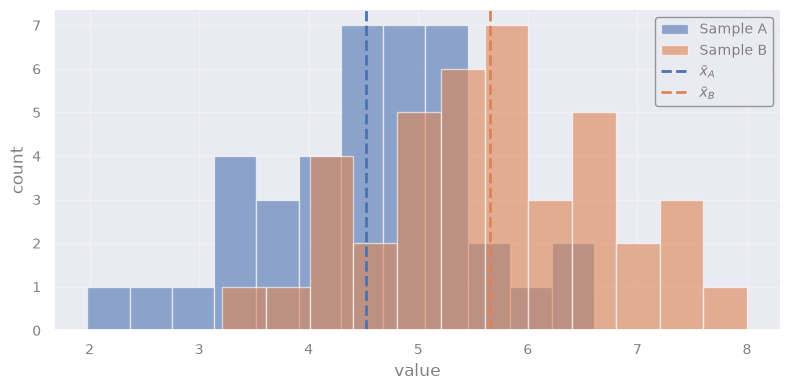

In [ ]:
rng = np.random.default_rng(seed=7)
X_a = rng.normal(loc=5.0, scale=1.2, size=40)
X_b = rng.normal(loc=5.6, scale=1.2, size=40)

plt.hist(X_a, bins=12, alpha=0.6, label="Sample A")
plt.hist(X_b, bins=12, alpha=0.6, label="Sample B")
plt.axvline(X_a.mean(), ls="--", color="C0", label=r"$\bar{x}_A$")
plt.axvline(X_b.mean(), ls="--", color="C1", label=r"$\bar{x}_B$")
plt.xlabel("value")
plt.ylabel("count")
plt.legend()
plt.show()

## t-test

**Model:** the data in each sample are i.i.d. draws from a Normal distribution.<br>
**Hypothesis:** the means are equal ($\mu_A = \mu_B$).

We use `stats.ttest_ind`.

In [ ]:
alpha = 0.05 # This is always set first!

t_stat, p_value = stats.ttest_ind(X_a, X_b)

print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.4f}")

if p_value < alpha:
    print(f"Decision: reject H0 (p < {alpha})")
else:
    print(f"Decision: cannot reject H0 (p >= {alpha})")


t-statistic = -4.828
p-value     = 0.0000
Decision: reject H0 (p < 0.05)


## Kolmogorov–Smirnov test

**Model:** the data in each sample are i.i.d. draws from a continuous distribution (no ties).<br>
**Hypothesis:** the whole shape of the distribution matches ($F_A = F_B$) — not just the mean.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [15 min]**</font>

**Objective:** Run a 2-sample Kolmogorov–Smirnov test on the same 2 samples used for the t-test, and compare its conclusion with the t-test's.

**Task:** Test whether `X_a` and `X_b` come from the same distribution.

_In particular, you must:_

1. **Use** the function `stats.ks_2samp` from `scipy.stats`.
2. **Pass** `X_a` and `X_b` to it — it returns the **D-statistic** and the **p-value**, in that order.
3. **Print** the D-statistic and the p-value.
4. **Decide** at $\alpha = 0.05$: reject $H_0$ if the p-value is below $\alpha$, otherwise do not reject.
5. **Compare** your conclusion with the t-test's conclusion above — are they the same? Why (not)?

**Data:** `X_a` and `X_b`, already generated above.

</div>


In [ ]:
# Student: Write your code here. Add blocks as you deem fit.

## Mann–Kendall test

**Model:** the data are i.i.d. under $H_0$ (no assumption on the shape of the distribution).<br>
**Hypothesis:** there is **no monotonic trend** over time.

We use `pymannkendall.original_test` on a simulated time series of yearly measurements.

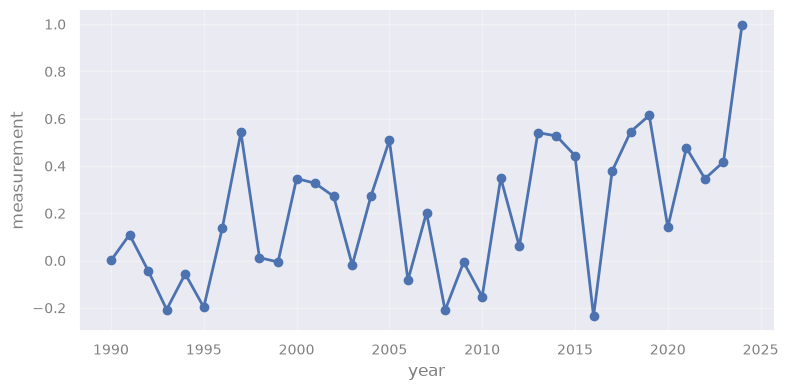

In [ ]:
import pymannkendall as mk

rng = np.random.default_rng(seed=7)
years = np.arange(1990, 2025)
trend = 0.02 * (years - years[0])
noise = rng.normal(loc=0.0, scale=0.3, size=years.size)
X = trend + noise

plt.plot(years, X, "o-")
plt.xlabel("year")
plt.ylabel("measurement")
plt.show()

In [ ]:
result = mk.original_test(X)

print(f"S-statistic = {result.s}")
print(f"p-value     = {result.p:.4f}")

alpha = 0.05
if result.p < alpha:
    print(f"Decision: reject H0 (p < {alpha})")
else:
    print(f"Decision: cannot reject H0 (p >= {alpha})")

S-statistic = 203.0
p-value     = 0.0041
Decision: reject H0 (p < 0.05)


# When you don't have the PDF

Every test seen so far rests on a **theoretical** reference PDF for the test statistic under $H_{0}$.<br>

That ingredient is not always available $\rightarrow$ 2 situations where the theoretical PDF is **missing**:

- The statistic of interest is **non-standard** — _e.g., a median, a quantile, a hardness ratio between 2 energy bands, a custom variability index of a light curve._<br>

- The data clearly violates the **assumptions** of the standard test — _heavy tails, strong asymmetry, very small $n$, or dependence_ — so the theoretical reference PDF is not trustworthy _even_ when it exists.

## Bootstrap Hypothesis Testing

The **bootstrap** sidesteps the problem by building the reference distribution **directly from the data**.

**Bootstrapping == random sampling with replacement**

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/Hypothesis_Testing/images/anim_bootstrap.gif?raw=1" width=700 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=700><center><br>
    Figure 2. Bootstrap resampling: each bootstrap sample is built by drawing 9 circles with replacement from the original sample, so the same circle can appear more than once in a row.
<br></center></td></tr></table>

<u>IMPORTANT:</u> There is **replacement** $-$ some samples can appear multiple times in a bootstrapped dataset.

Bootstrapping is a **heuristic** procedure: it treats the empirical sample as a proxy for the population and resamples from it.

> _It follows that_ $\rightarrow$ _$\hat{T}$ recomputed across bootstrapped samples scatters like across real new samples — giving us its PDF._

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**Bootstrap one-sample test**

For a generic statistic $\hat{T}$ with null $H_{0}: T = T_{0}$:

1. Compute $\hat{T}_{\rm obs}$ on the original sample $\{x_{1}, \dots, x_{n}\}$.

2. **Shift the sample** so that the null holds — produce $\{x_{i}^{\prime}\}$ such that the statistic evaluated on it equals $T_{0}$.<br>
_For tests on a centre, this is $x_{i}^{\prime} = x_{i} - \hat{T}_{\rm obs} + T_{0}$._

3. Draw $B$ samples of size $n$ with replacement from $\{x_{i}^{\prime}\}$; on each, compute $\hat{T}_{b}^{*}$.

4. The collection $\{\hat{T}_{1}^{*}, \dots, \hat{T}_{B}^{*}\}$ is the bootstrap reference distribution **under $H_{0}$**.

5. The two-sided p-value is the empirical tail mass beyond the observed deviation:

$$ p_{\rm value} \;\approx\; \frac{1}{B}\sum_{b=1}^{B} \mathbf{1}\!\left[\,\bigl|\hat{T}_{b}^{*} - T_{0}\bigr| \;\geq\; \bigl|\hat{T}_{\rm obs} - T_{0}\bigr|\,\right]. \tag{2}$$

</div>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

The **price**: we lose the clean theoretical guarantee — bootstrap works because of asymptotic results and accumulated empirical evidence.

The **reward**: it works for almost any statistic, on almost any data, with the same handful of lines of code.

</div>

## Example: median GC log-mass

Let's suppose we want to compare the **median** value of a model with the data.

- **Data:** log-masses of 120 GCs from another survey.
- **Model:** predicts a **median** log-mass $m_{0} = 5.2$.
- **Hypothesis:** $H_0: m = m_0$.

Let's look at the data first.

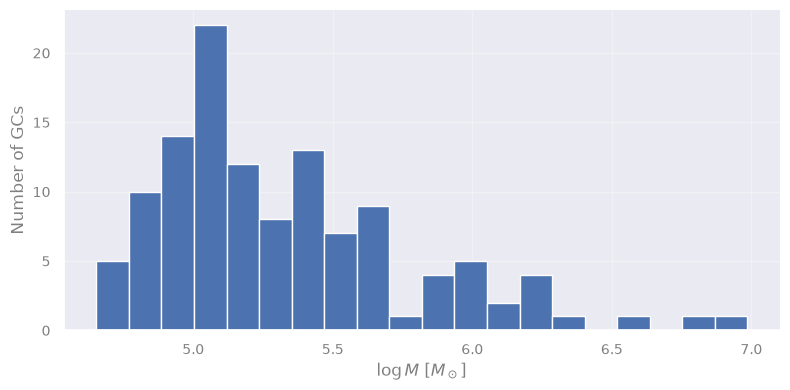

n GCs          = 120
sample median  = 5.19
model m0       = 5.2
observed gap   = -0.01


In [ ]:
# ── Load and display the new GC sample ─────────────────────────────────────
df_gc = pd.read_csv("data/GC_logmasses_skewed.csv", header=None, names=["log_mass"])
X_GC = df_gc["log_mass"].to_numpy()

n_GC = X_GC.size

plt.hist(X_GC, bins=20)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("Number of GCs")
plt.show()

m0 = 5.2
m_obs = float(np.median(X_GC))

print(f"n GCs          = {n_GC}")
print(f"sample median  = {m_obs:.2f}")
print(f"model m0       = {m0}")
print(f"observed gap   = {m_obs - m0:+.2f}")

We now bootstrap **10,000** samples and apply Equation 2.

In [ ]:
# ── Bootstrap null distribution of the median ─────────────────────────────

# Seed the random generator, so the resampling is reproducible.
rng = np.random.default_rng(seed=42)

# Number of bootstrapped samples to draw.
B = 10_000

# Shift the sample so that its median is exactly m0.
'''This enforces H0 on the resampling pool: the bootstrapped samples will
scatter around m0, i.e. they describe a world where H0 is true.'''
X_GC_shifted = X_GC - m_obs + m0

# Draw B x n random indices between 0 and n-1, with repetitions allowed.
boot_idx = rng.integers(0, n_GC, size=(B, n_GC))

# Apply indexes to obtained B bootstrapped samples.
boot_samples = X_GC_shifted[boot_idx]

# Compute the statistic (the median) on each row.
'''These B values are the empirical PDF of the median under H0.'''
boot_T = np.median(boot_samples, axis=1)

We can also visualize our **empirical PDF for the median**.

This is simply the **histogram** of the 10,000 medians measured on the 10,000 bootstrapped samples!

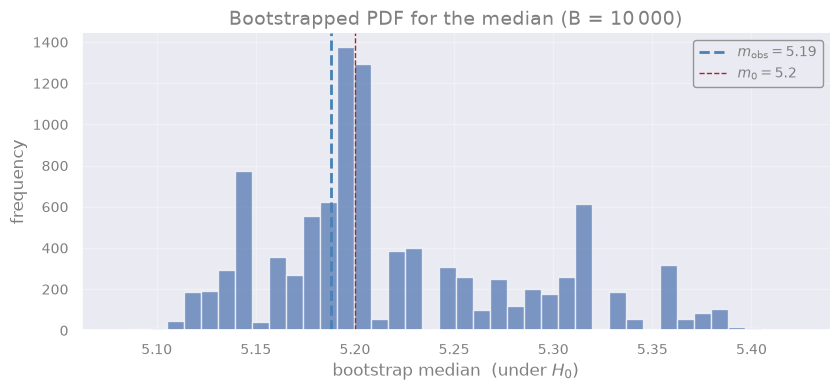

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(boot_T, bins=40, color="C0", alpha=0.7, edgecolor="white")
ax.axvline(m_obs, color="steelblue", lw=2, ls="--", label=fr"$m_{{\mathrm{{obs}}}} = {m_obs:.2f}$")
ax.axvline(m0,    color="firebrick", lw=1, ls="--", label=fr"$m_0 = {m0}$")
ax.set_xlabel("bootstrap median  (under $H_0$)")
ax.set_ylabel("frequency")
ax.set_title(r"Bootstrapped PDF for the median (B = 10$\,$000)")
ax.legend()
plt.show()

In [ ]:
# Two-sided bootstrap p-value
p_boot = np.mean(np.abs(boot_T - m0) >= abs(m_obs - m0))
print(f"bootstrap p-value (two-sided) = {p_boot:.4f}")

bootstrap p-value (two-sided) = 0.6980


## Caveats — the bootstrap is not magic.

It **inherits the limits of the sample** $\rightarrow$ A _small_ or _biased_ sample produces a _small_ or _biased_ PDF.

- The PDF is **discrete**: a bootstrapped sample only contains values copied from the original one.
  >_A statistic like the median can only take a few distinct values — hence the spiky histogram above._

- It is **unsuitable** for statistics dominated by the **extremes** (_maximum, minimum_), where resampling cannot create new tail behaviour.
  
- It assumes **independent** observations.<br>
  > _Time-series and clustered data require block or stratified bootstrap variants._

- The number of resamples $B$ controls the **resolution** of the p-value $\leftarrow$ $B = 10\,000$ resolves p-values down to about $10^{-4}$.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**Bootstrap two-sample test**

For a difference between 2 samples, the natural counterpart is a <strong>permutation test</strong>:

1. Merge the 2 samples into 1 single dataset
2. Shuffle the labels
3. Recompute the statistic of interest
4. Repeat $B$ times.
  
The shuffle enforces the null "there is no difference between the samples". A two-sample bootstrap variant resamples each sample separately and tracks the difference of statistics across the resamples.

</div>


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [45 min]**</font>

**Objective:** Run a bootstrap hypothesis test on the **mean** of a heavy-tailed distribution.

**Context:** An X-ray monitoring campaign observes an Active Galactic Nucleus (AGN).<br>
Archival data set its **quiescent** (non-flaring) mean flux at $\mu_{0} = 60$ (in units of $10^{-14}\ \mathrm{erg\ s^{-1}\ cm^{-2}}$).

The campaign collected **180 flux measurements** and we want to test whether the source's true mean flux is **above** the quiescent baseline<br>
_i.e. whether the AGN has brightened._

**Task**: Run a bootstrapped hypothesis test.

_In particular, you must:_

1. **Generate** the dataset using the cell provided right below — do **not** change the seed.
2. **Set** an $\alpha = 0.05$.
3. **Compute** the observed sample mean $\bar{x}$.
4. **State** $H_{0}$ and $H_{1}$, choose a **one-sided** alternative ($H_{1}: \mu > \mu_{0}$).
5. **Build** the bootstrap reference distribution of the mean under $H_{0}$ with $B = 10\,000$ resamples.
6. **Shift** $x_{i}^{\prime} = x_{i} - \bar{x} + \mu_{0}$ to enforce the null on the resampling pool.
7. **Compute** the one-sided bootstrap p-value.
8. **Plot** the bootstrap null distribution with $\bar{x}$ and $\mu_{0}$ marked.
9. **Report** the conclusion in plain language.

</div>

In [ ]:
# ── Given data — do not change the seed ───────────────────────────────────
n_AGN = 180

exercise_rng = np.random.default_rng(seed=2604_4003)
X_AGN = exercise_rng.lognormal(mean=np.log(60), sigma=0.55, size=n_AGN)

print(f"n measurements = {n_AGN}")
print(f"sample mean    = {X_AGN.mean():.1f}  (1e-14 erg/s/cm2)")
# print(f"sample median  = {np.median(X_AGN):.1f}  (1e-14 erg/s/cm2)")

n measurements = 180
sample mean    = 70.3  (1e-14 erg/s/cm2)


In [ ]:
X_AGN.shape

(180,)

In [ ]:
# Student: Write your code here. Add blocks as you deem fit.

# Closing remarks

## What we conclude

In Science, we can only **disprove** theories, <u>never</u> prove them.

For example, if a theory postulates:
> _"All Neutron Stars (NSs) have masses below 2.5 $M_\odot$"_

- to confirm it, one needs to observe all NSs in existence.
- to disprove it, one just needs a single NS above 2.5 $M_\odot$.

**Implication 1**: "_Rejecting at $\alpha = 0.05$_" means that, in a world where $H_0$ is true, our procedure would wrongly reject 5% of the time.

> _Note the fine print: it's a guarantee about the procedure's long-run behavior assuming $H_0$ is true._<br>
> _<u>Not</u> the probability that <u>this</u> particular rejection is a mistake._

We make this statement **before** even running the test!

**Implication 2**: 100%-$p$-value is <u>not</u> the probability for the model (_hypothesis_) to be correct

> _There are infinite other models under which the $p$-value would be above $\alpha$._


## In particular: p-values

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

The **p-value** is the probability, computed under $H_{0}$, of observing a test statistic <strong>at least as extreme</strong> as the one we obtained:

$$ p = P(\,|T| \geq |t_{\rm obs}|\, \mid H_{0}). \tag{3}$$

Decision rule: reject $H_{0}$ if $p < \alpha$, do not reject otherwise.

</div>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

**Common misinterpretations of the p-value — all wrong:**

_“The p-value is the probability that $H_0$ is true.”_<br>
> No. $H_0$ is a fixed claim, not a random variable.

_“A small p-value proves the alternative.”_<br>
> No. It only quantifies how surprising the data is under $H_0$.

_“A large p-value means $H_0$ is true.”_<br>
> No. It only means the data does not contradict $H_0$ strongly enough at the chosen $\alpha$.

_“The p-value measures effect size.”_<br>
> No. A trivially small effect can yield a tiny $p$-value with a large enough sample.

</div>

Two extra hazards to know about:

- **p-hacking.** Trying many tests and reporting only the smallest p-value<br>
$\rightarrow$ Choose the appropriate test <u>before</u> testing, and stick to it!


- **Multiple comparisons.** Running $m$ independent tests at $\alpha = 0.05$ inflates the chance of *at least one* false positive to roughly $1 - (1 - \alpha)^{m}$.<br>
$\rightarrow$ Corrections such as **Bonferroni** or **FDR** are the standard remedies.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

Always report <strong>three things</strong> together: the <strong>p-value</strong>, the <strong>effect size</strong> (_e.g., difference w.r.t. the expected value_), and a <strong>confidence interval</strong>.

The trio answers <em>is it real, how big is it, and how precise are we</em> — none of them alone is enough.

</div>


# Solutions

## Solution — Kolmogorov–Smirnov test exercise

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>

In [ ]:
ks_stat, p_value = stats.ks_2samp(X_a, X_b)

print(f"D-statistic = {ks_stat:.3f}")
print(f"p-value     = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Decision: reject H0 (p < {alpha})")
else:
    print(f"Decision: cannot reject H0 (p >= {alpha})")


D-statistic = 0.475
p-value     = 0.0002
Decision: reject H0 (p < 0.05)


**Observations**:

Both the t-test AND the K-S test reject $H_0$ (since `X_a` and `X_b` differ by construction).

In general, 2 tests can **disagree** $\rightarrow$ Always pick the one whose hypothesis is closer to your needs.



<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>

## Solution — Bootstrap AGN flux exercise

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>


In [ ]:
# H0: mu = 60     H1: mu > 60     (one-sided, right tail)

mu0    = 60.0
x_bar  = float(X_AGN.mean())

print(f"observed sample mean = {x_bar:.2f}  (1e-14 erg/s/cm2)")
print(f"quiescent baseline   = {mu0:.2f}")
print(f"observed gap         = {x_bar - mu0:+.2f}")

observed sample mean = 70.26  (1e-14 erg/s/cm2)
quiescent baseline   = 60.00
observed gap         = +10.26


In [ ]:
rng = np.random.default_rng(seed=42)   # seed, so the resampling is reproducible

B = 10_000
X_AGN_shifted = X_AGN - x_bar + mu0     # enforce H0 on the resampling pool

boot_idx     = rng.integers(0, n_AGN, size=(B, n_AGN))
boot_samples = X_AGN_shifted[boot_idx]
boot_T       = boot_samples.mean(axis=1)

p_boot = np.mean(boot_T >= x_bar)            # one-sided, right tail
print(f"bootstrap p-value (one-sided) = {p_boot:.4f}")

bootstrap p-value (one-sided) = 0.0036


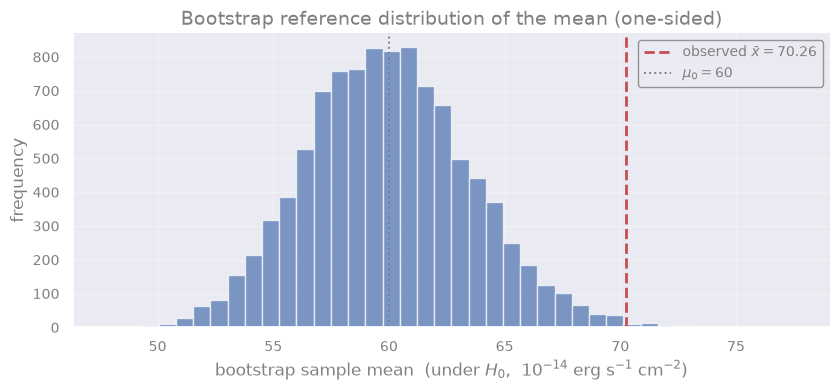

In [ ]:
# Visualise the bootstrap reference distribution
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(boot_T, bins=40, color="C0", alpha=0.7, edgecolor="white")

ax.axvline(x_bar, color="C3", lw=2, ls='--', label=fr"observed $\bar x = {x_bar:.2f}$")
ax.axvline(mu0,   color="gray", lw=1.4, ls=":", label=fr"$\mu_0 = {mu0:.0f}$")
ax.set_xlabel(r"bootstrap sample mean  (under $H_0$,  $10^{-14}$ erg s$^{-1}$ cm$^{-2}$)")
ax.set_ylabel("frequency")
ax.set_title("Bootstrap reference distribution of the mean (one-sided)")
ax.legend()
plt.show()

**Observations:**

The observed mean flux is well above the quiescent baseline of 60, and the one-sided bootstrap p-value falls below 0.05 — the data **rejects** $H_{0}$ at the 5% level.

$\rightarrow$ We can claim the AGN's true mean flux is statistically higher than the quiescent baseline: the source has brightened.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>


In [ ]:
#EOF